## 0. Imports

In [51]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.api import OLS, add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from scipy import stats
from scipy.optimize import curve_fit

import altair as alt
alt.data_transformers.disable_max_rows()

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)

## 1. Configuration

> **Edit this cell to change variables, shock sizes, or asset groups.**

In [52]:
# ── Data path ────────────────────────────────────────────────
DATA_PATH = '/Users/Stefania/Dropbox/WorkingPapers_Publications/DebtRank/REVISION/Updated_data/new/'

## 2. Data Loading & Preparation

Run once. Produces `regr_pool_users` — the master dataset used by both crypto and stablecoin sections.

In [53]:
# ── Load raw files ───────────────────────────────────────────
print("Loading data...")

dr = pd.read_csv(DATA_PATH + 'liquidation.csv')
dr['shockAsset'] = dr['shock'].str.replace('c', '', regex=False)
dr['asset_group'] = np.where(
    dr['shockAsset'].isin(['ETH', 'WBTC']), 'Crypto',
    np.where(dr['shockAsset'].isin(['USDC', 'DAI']), 'Stablecoin', 'Other')
)

pool_stats = pd.read_csv(DATA_PATH + 'pool_statistics_with_cf.csv')
pool_stats['shockAsset'] = pool_stats['node'].str.replace('c', '', regex=False)

net_stats = pd.read_csv(DATA_PATH + 'network_statistics.csv')

cen_pool = pd.read_csv(DATA_PATH + 'pool_centralities.csv')
cen_pool['shockAsset'] = cen_pool['node'].str.replace('c', '', regex=False)

all_n = pd.read_csv(DATA_PATH + 'shockAsset_lenders_borrowers_new.csv').sort_values('date')
all_n['date'] = pd.to_datetime(all_n['date'])
all_n['shockAsset'] = all_n['symbol'].str.replace('c', '', regex=False)

print("Done.")

Loading data...
Done.


In [54]:
pool_stats[['date', 'shockAsset', 'pctDeposit', 'pctBorrow', 'pctEquity']].rename(columns={
      'pctDeposit': 'shareDeposit',                                                          
      'pctBorrow':  'shareBorrow',                                                           
      'pctEquity':  'shareEquity'                                                            
  })           

,date,shockAsset,shareDeposit,shareBorrow,shareEquity
0,2020-01-01,BAT,0.006680,2.289820e-03,0.000516
1,2020-01-01,DAI,0.159804,3.421849e-01,0.571235
2,2020-01-01,ETH,0.379802,1.182162e-02,0.003153
3,2020-01-01,REP,0.112051,1.971574e-03,0.000364
4,2020-01-01,SAI,0.048236,7.874537e-02,0.099439
...,...,...,...,...,...
24332,2024-06-15,USDP,0.000401,1.561052e-03,0.000150
24333,2024-06-15,USDT,0.181990,5.791646e-01,0.088551
24334,2024-06-15,WBTC,0.291670,4.308659e-03,0.000017
24335,2024-06-15,YFI,0.000083,7.408324e-08,0.000061


In [55]:
# ── Merge pool stats + bad debt ──────────────────────────────
regr_pool = pd.merge(pool_stats, dr, on=['date', 'shockAsset'], how='left')
regr_pool['date']  = pd.to_datetime(regr_pool['date'], errors='coerce')
regr_pool['year']  = regr_pool['date'].dt.year
regr_pool['month'] = regr_pool['date'].dt.month

regr_pool['assets']          = regr_pool['in_weight'] + regr_pool['ext_assets']
#regr_pool['log_assets']      = np.log1p(regr_pool['assets'])
regr_pool['equity_share']    = regr_pool['equity']     / regr_pool['assets']
regr_pool['extassets_share'] = regr_pool['ext_assets'] / regr_pool['assets']

total_assets = (regr_pool.groupby('date')['assets'].sum()
                .reset_index(name='total_assets'))
regr_pool = regr_pool.merge(total_assets, on='date', how='left')

regr_pool['size_share']    = regr_pool['assets']      / regr_pool['total_assets']
# regr_pool['self_borrow']   = (regr_pool['pctSelfBorrow'] * regr_pool['in_weight']) / regr_pool['total_assets']
regr_pool['self_borrow_2'] = (regr_pool['pctSelfBorrow'] * regr_pool['in_weight']) / regr_pool['assets']

# ── Merge centralities + network stats ───────────────────────
for df in [regr_pool, cen_pool, net_stats]:
    df['date'] = pd.to_datetime(df['date'])

cen_net         = cen_pool.merge(net_stats, on='date', how='left')
regr_pool_final = regr_pool.merge(cen_net, on=['date', 'shockAsset'], how='left')

# ── Dependent and independent variables ──────────────────────
#regr_pool_final['TD']                = regr_pool_final['T'] + regr_pool_final['D']
#regr_pool_final['log_out_weight']    = np.log(regr_pool_final['out_weight'])
regr_pool_final['utilization_ratio'] = 1 - (
    regr_pool_final['ext_assets'] /
    (regr_pool_final['ext_assets'] + regr_pool_final['in_weight'])
)
#regr_pool_final['log_totCollateral'] = np.log(regr_pool_final['totCollateral'])
#regr_pool_final['log_B']             = np.log(regr_pool_final['B'])
regr_pool_final['share_B']           = regr_pool_final['B'] / regr_pool_final['assets']
#regr_pool_final['log_share_B']       = np.log(regr_pool_final['share_B'])
regr_pool_final['share_T']           = (regr_pool_final['T'] - regr_pool_final['Tp']) / regr_pool_final['assets']
regr_pool_final['delta_T']           = (regr_pool_final['T'] - regr_pool_final['Tp'])

# ── Merge user/collateral neighbourhood features ─────────────
regr_pool_users = regr_pool_final.merge(all_n, on=['date', 'shockAsset'], how='left')

# Log-transform skewed neighbourhood variables
# Add new log-transforms here if you add new raw variables above
#for log_col, raw_col in [
#    ('log_collaterals-in_weight-sum',   'collaterals-in_weight-sum'),
#    ('log_collaterals-equity-wavg',     'collaterals-equity-wavg'),
#    ('log_collaterals-out_weight-wavg', 'collaterals-out_weight-wavg'),
#    ('log_collaterals-out_degree-wavg', 'collaterals-out_degree-wavg'),
#    ('log_borrowers-out_weight-wavg',   'borrowers-out_weight-wavg'),
#    ('log_borrowers-equity-wavg',       'borrowers-equity-wavg'),
#]:
#    regr_pool_users[log_col] = np.log(regr_pool_users[raw_col])

regr_pool_users['asset_group'] = np.where(
    regr_pool_users['shockAsset'].isin(['ETH', 'WBTC']), 'Crypto',
    np.where(regr_pool_users['shockAsset'].isin(['USDC', 'DAI']),
             'Stablecoin', 'Other')
)

print(f"Master dataset ready: {regr_pool_users.shape}")
print(f"Assets: {sorted(regr_pool_users['shockAsset'].unique())}")

Master dataset ready: (96508, 415)
Assets: ['AAVE', 'BAT', 'COMP', 'DAI', 'ETH', 'FEI', 'LINK', 'REP', 'SAI', 'SUSHI', 'TUSD', 'UNI', 'USDC', 'USDP', 'USDT', 'WBTC', 'YFI', 'ZRX']


In [56]:
print(regr_pool_users.columns.tolist())

['date', 'node_x', 'collateralFactor', 'in_degree', 'in_weight', 'in_weight_hhi', 'out_degree', 'out_weight', 'out_weight_hhi', 'in_out_ratio', 'ext_assets', 'equity', 'selfBorrowUSD', 'pctSelfBorrow_x', 'usedCollateralUSD', 'pctUsedCollateral', 'pctDeposit', 'pctBorrow', 'pctEquity', 'shockAsset', 'shock', 'size', 'C', 'D', 'T', 'E', 'Cp', 'Dp', 'Tp', 'B', 'Ep', 'liquidated_nbd', 'liquidated_bd', 'seized_nbd', 'seized_bd', 'asset_group', 'year', 'month', 'assets', 'equity_share', 'extassets_share', 'total_assets', 'size_share', 'self_borrow_2', 'node_y', 'eigenvector', 'pagerank', 'hub', 'authority', 'core', 'katz', 'laplacian', 'betweeness', 'closeness', 'borrowing', 'funding', 'eigenvector_scaled', 'pagerank_scaled', 'hub_scaled', 'authority_scaled', 'core_scaled', 'katz_scaled', 'laplacian_scaled', 'betweeness_scaled', 'closeness_scaled', 'borrowing_scaled', 'funding_scaled', 'nPool', 'nUsers', 'nPureLenders', 'nBorrowers', 'nPureLenders100', 'nBorrowers100', 'nNewPureLenders', 'nN

# 2. ANALYSIS OF LIQUIDITY

# 2.1 Descriptive Statistics

In [57]:
lp = pd.read_csv(DATA_PATH + 'liquidation_pools.csv')
lp['shockAsset'] = lp['shock'].str.replace('c', '', regex=False)
lp['otherAsset'] = lp['symbol'].str.replace('c', '', regex=False)

lp['date'] = pd.to_datetime(lp['date'])

In [58]:
# Merge Liquidation_pools with other dataset

lp_own = lp[lp['shockAsset'] == lp['otherAsset']].copy()

rename_map = {
    'C':  'C_pool',
    'D':  'D_pool',
    'T':  'T_pool',
    'E':  'E_pool',
    'Cp': 'Cp_pool',
    'Dp': 'Dp_pool',
    'Tp': 'Tp_pool',
    'B':  'B_pool',
    'Ep': 'Ep_pool',
}
lp_own = lp_own.rename(columns=rename_map)

lp_own = lp_own.rename(columns={'date_pool': 'date'})


In [59]:
final = pd.merge(regr_pool_users, lp_own, on=['date', 'size', 'shockAsset'], how='left')
final['shareT_pool'] = (final['T_pool'] - final['Tp_pool']) / final['assets']

### Structural Break

In [60]:
# WARNING: Set arbitrary break date !
break_date = pd.to_datetime('2021-01-01')  # or use this fixed date if you prefer

In [61]:
lp = pd.read_csv(DATA_PATH + 'liquidation_pools.csv')
lp['shockAsset'] = lp['shock'].str.replace('c', '', regex=False)
lp['otherAsset'] = lp['symbol'].str.replace('c', '', regex=False)

lp['date'] = pd.to_datetime(lp['date'])

In [62]:
new_health = pd.read_csv(DATA_PATH + 'shockAsset_collateral_filtered.csv')
new_health['date'] = pd.to_datetime(new_health['date'])

In [63]:
merge_keys = ['date', 'shockAsset', 'size']
common_cols = [c for c in new_health.columns 
               if c in final.columns and c not in merge_keys]
print(f"Columns to be replaced: {common_cols}")
print(f"New columns from new_health: {[c for c in new_health.columns if c not in final.columns and c not in merge_keys]}")


Columns to be replaced: ['collaterals-in_weight-count', 'collaterals-out_weight-count', 'collaterals-depositUSD-sum', 'collaterals-in_degree-sum', 'collaterals-in_weight-sum', 'collaterals-in_weight_hhi-sum', 'collaterals-out_degree-sum', 'collaterals-out_weight-sum', 'collaterals-out_weight_hhi-sum', 'collaterals-in_out_ratio-sum', 'collaterals-ext_assets-sum', 'collaterals-equity-sum', 'collaterals-selfBorrowUSD-sum', 'collaterals-pctSelfBorrow-sum', 'collaterals-usedCollateralUSD-sum', 'collaterals-pctUsedCollateral-sum', 'collaterals-maxCollateralUSD-sum', 'collaterals-health-sum', 'collaterals-pctDeposit-sum', 'collaterals-debtToCollateral-sum', 'collaterals-depositUSD-avg', 'collaterals-in_degree-avg', 'collaterals-in_weight-avg', 'collaterals-in_weight_hhi-avg', 'collaterals-out_degree-avg', 'collaterals-out_weight-avg', 'collaterals-out_weight_hhi-avg', 'collaterals-in_out_ratio-avg', 'collaterals-ext_assets-avg', 'collaterals-equity-avg', 'collaterals-selfBorrowUSD-avg', 'coll

In [64]:
final_updated = (final
                 .drop(columns=common_cols)
                 .merge(new_health.assign(shockAsset=new_health['symbol'].str.replace('c', '', regex=False))
                                  .drop(columns=['symbol']),
                        on=['date', 'shockAsset'], how='left'))

print(f"Original shape: {final.shape}")
print(f"Updated shape:  {final_updated.shape}")
print(f"Unmatched rows: {final_updated['collaterals-health-wavg'].isna().sum()}")


Original shape: (96508, 432)
Updated shape:  (288846, 433)
Unmatched rows: 334


### 3. Features' selection, Analysis of liquidation, Regressions 

### 3.1 Features' dictionary

In [65]:
# Create dictionary of column groups for pool-level features

pool_cols = {
    'own': [
        'ext_assets', 'equity', 
        # 'selfBorrowUSD', 'pctSelfBorrow_x', 'self_borrow',
        'usedCollateralUSD', 'pctUsedCollateral', 'pctDeposit', 'pctBorrow', 'pctEquity',
        'assets', 'log_assets', 'equity_share', 'extassets_share',
        'size_share',  'self_borrow_2',
        'log_out_weight', 'utilization_ratio', 'C_pool', 'D_pool', 'T_pool', 'E_pool', 'collateralFactor', 
         'in_degree', 'in_weight', 'in_weight_hhi', 'out_degree', 'out_weight', 'out_weight_hhi', 'in_out_ratio' 
    ],
    'centrality': [
        'eigenvector', 'pagerank', 'hub', 'authority', 'core',
        'katz', 'laplacian', 'betweeness', 'closeness', 'borrowing', 'funding',
        'eigenvector_scaled', 'pagerank_scaled', 'hub_scaled', 'authority_scaled',
        'core_scaled', 'katz_scaled', 'laplacian_scaled', 'betweeness_scaled',
        'closeness_scaled', 'borrowing_scaled', 'funding_scaled',
        'density', 'reciprocity', 'biDensity', 'biAvgClustering', 'biAvgLatapyClustering'
    ],
    'aggregate': [
        'nPool', 'nUsers', 'nPureLenders', 'nBorrowers',
        'nPureLenders100', 'nBorrowers100',
        'nNewPureLenders', 'nNewBorrowers', 'nNewPureLenders100', 'nNewBorrowers100',
        'totDeposit', 'totPureLender', 'totCollateral', 'totBorrow', 'utilization',
        'totNewDeposit', 'totNewBorrow', 'newUtilization',
        'nDeposit', 'nBorrow', 'nDeposit100', 'nBorrow100',
        'nNewDeposit', 'nNewBorrow', 'nNewDeposit100', 'nNewBorrow100',
        'C', 'D', 'T', 'E', 'TD', 'total_assets'
    ],
    'cross_pool': [
        c for c in final.columns if c.startswith('pools_')
    ]
}

# Verify all columns exist in final
for group, cols in pool_cols.items():
    missing = [c for c in cols if c not in final.columns]
    if missing:
        print(f"[{group}] Missing: {missing}")
    else:
        print(f"[{group}] OK — {len(cols)} columns")


[own] Missing: ['log_assets', 'log_out_weight']
[centrality] OK — 27 columns
[aggregate] Missing: ['TD']
[cross_pool] OK — 72 columns


In [66]:
users_cols = {
    'network': [
        c for c in final.columns if c.startswith('users_') and
        any(x in c for x in ['in_degree', 'in_weight', 'out_degree', 'out_weight', 'in_out_ratio'])
    ],
    'financial': [
        c for c in final.columns if c.startswith('users_') and
        any(x in c for x in ['equity', 'health', 'pctSelfBorrow'])
    ]
}

for group, cols in users_cols.items():
    print(f"[{group}] {len(cols)} columns: {cols}")


[network] 54 columns: ['users_in_degree_mean', 'users_in_degree_std', 'users_in_degree_25%', 'users_in_degree_50%', 'users_in_degree_75%', 'users_in_degree_skew', 'users_in_degree_kurtosis', 'users_in_weight_mean', 'users_in_weight_std', 'users_in_weight_25%', 'users_in_weight_50%', 'users_in_weight_75%', 'users_in_weight_skew', 'users_in_weight_kurtosis', 'users_in_weight_hhi_mean', 'users_in_weight_hhi_std', 'users_in_weight_hhi_25%', 'users_in_weight_hhi_50%', 'users_in_weight_hhi_75%', 'users_in_weight_hhi_skew', 'users_in_weight_hhi_kurtosis', 'users_out_degree_mean', 'users_out_degree_std', 'users_out_degree_25%', 'users_out_degree_50%', 'users_out_degree_75%', 'users_out_degree_skew', 'users_out_degree_kurtosis', 'users_out_weight_mean', 'users_out_weight_std', 'users_out_weight_25%', 'users_out_weight_50%', 'users_out_weight_75%', 'users_out_weight_skew', 'users_out_weight_kurtosis', 'users_out_weight_hhi_mean', 'users_out_weight_hhi_std', 'users_out_weight_hhi_25%', 'users_out

In [67]:
features = {                                                                                     
      'pool_own': pool_cols['own'],                                                                
      'pool_centrality': pool_cols['centrality'],                                                  
      'pool_aggregate': pool_cols['aggregate'],                                                    
      'pool_cross': pool_cols['cross_pool'],                                                       
      'users_network': users_cols['network'],                                                    
      'users_financial': users_cols['financial'],
      'outcome'        : ['log_B', 'share_B', 'log_share_B', 'share_T', 'delta_T', 'Cp', 'Dp', 'Tp', 'B', 'Ep', 'Cp_pool', 'Dp_pool',           
                            'Tp_pool', 'B_pool', 'Ep_pool', 'shareT_pool']                                                   
  }

In [68]:
# Pool additions                                                                               
features['shock']    = ['date', 'year', 'month', 'shockAsset', 'size']   
                                                                                                   
# Collaterals & borrowers: split by topic                                                        
_financial_keys = ['depositUSD', 'borrowUSD', 'ext_assets', 'equity', 'selfBorrowUSD',           
                     'pctSelfBorrow', 'usedCollateralUSD', 'pctUsedCollateral', 'maxCollateralUSD',
                     'health', 'pctBorrow', 'pctDeposit', 'debtToCollateral',
                     'lenders100_hhiDeposit', 'borrowers100_hhiBorrow',
                     'borrowers100_health_mean', 'borrowers100_health_std',
                     'borrowers100_health_25%', 'borrowers100_health_50%', 'borrowers100_health_75%',
                     'borrowers100_health_wavg', 'borrowers100_health_skew', 'borrowers100_health_kurtosis',
                     'users_hhiDeposit', 'users_hhiBorrow', 'users_hhiEquity']
                      
_network_keys   = ['in_degree', 'in_weight', 'out_degree', 'out_weight', 'in_out_ratio']         
                                                                                                   
for prefix in ['collaterals', 'borrowers']:                                                    
      features['users_financial'] += [c for c in final.columns if c.startswith(f'{prefix}-')       
                                       and any(k in c for k in _financial_keys)]                   
      features['users_network']   += [c for c in final.columns if c.startswith(f'{prefix}-')
                                       and any(k in c for k in _network_keys)                      
                                       and c not in features['users_financial']]                 
                                                                                                   
features['users_financial'] += ['log_borrowers-equity-wavg',                                     
                                   'users_hhiDeposit', 'users_hhiBorrow', 'users_hhiEquity']
features['users_network']   += ['log_collaterals-in_weight-sum', 'log_collaterals-equity-wavg',  
                                   'log_collaterals-out_weight-wavg',                              
                                  'log_collaterals-out_degree-wavg',
                                   'log_borrowers-out_weight-wavg']                                
                                                                                                   
# Clean pool groups: remove misplaced columns
_exclude = ['borrowers-', 'collaterals-', 'users_hhiDeposit', 'users_hhiBorrow',                 
              'users_hhiEquity']                                                                               
for key in ['pool_own', 'pool_aggregate', 'pool_centrality', 'pool_cross']:
      features[key] = [c for c in features[key]                                                    
                       if not any(c.startswith(e) if e.endswith('-') else c == e for e in          
                          _exclude)]                                                                                       
                                                                                                   
# Deduplicate all groups                                                                         
features = {k: list(dict.fromkeys(v)) for k, v in features.items()}

# Remove features ending with 'USD' from all feature lists
                                                                                                                                                                                               
def drop_usd(lst):                                                                   
      return [f for f in lst if 'USD' not in f]                                                                                                                                      
                                                                                                                                                                                                                                                                                                                                                                                           
# Fix features dict (cell 59) — needs explicit update since it's a separate reference                                                                                                        
features['pool_own'] = drop_usd(features['pool_own'])                                                                                                                                        
features['users_financial'] = drop_usd(features['users_financial'])   

# Fix _financial_keys (cell 60)                                                                                                                                                              
_financial_keys = drop_usd(_financial_keys)                                                                                                                                                  
                                                                                                                                                                                               
# Verification                                                                                                                                                                               
for k, v in features.items():                                                        
      remaining = [f for f in v if 'USD' in f]                                         
      if remaining:                                                                    
          print(f"features['{k}']: {remaining}")                                       
print("Done — no output above means all USD features removed.")   

def drop_100(lst):                                                                                                                                                                           
      return [f for f in lst if not f.endswith('100')]                                                                                                                                         
                                                                                                                                                                                                                                                                                                                                                                                     
# Fix features dict (cell 59) — explicit update needed                                                                                                                                       
features['pool_aggregate'] = drop_100(features['pool_aggregate'])                                                                                                                            
                                                                                                                                                                                               
# Verification                                                                                                                                                                               
print("100-ending remaining in features['pool_aggregate']:", [f for f in features['pool_aggregate'] if f.endswith('100')])  

# Remove features ending with '%' from all feature lists                                                                                                                                     
                                                                                                                                                                                               
def drop_pct(lst):                                                                                                                                                                           
      return [f for f in lst if not f.endswith('%')]                                                                                                                                           
                                                                                                                                                                                               
_financial_keys              = drop_pct(_financial_keys)                                                                                                                                     
features['users_financial']  = drop_pct(features['users_financial'])                                                                                                                         
features['pool_cross']       = drop_pct(features['pool_cross'])                                                                                                                              
features['users_network']    = drop_pct(features['users_network'])                                                                                                                           
                                                                                                                                                                                               
# Verification                                                                                                                                                                               
for name, lst in [('_financial_keys', _financial_keys),                                                                                                                                      
                    ('users_financial', features['users_financial']),                                                                                                                          
                    ('pool_cross',      features['pool_cross']),                                                                                                                               
                    ('users_network',   features['users_network'])]:                                                                                                                           
      remaining = [f for f in lst if f.endswith('%')]                                                                                                                                          
      print(f"%-ending remaining in {name}: {remaining or 'None'}") 

# Remove features starting with 'log_' from all feature lists                                                                                                                                
                                                                                                                                                                                               
def drop_log(lst):                                                                                                                                                                           
      return [f for f in lst if not f.startswith('log_')]  
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
# Cell 59/60 — features dict (all groups including users_network)
for key in features:
      features[key] = drop_log(features[key])

# Verification
for k, v in features.items():
      remaining = [f for f in v if f.startswith('log_')]
      if remaining:
          print(f"log_ remaining in features['{k}']: {remaining}")
print("Done")    

# Remove features ending with 'sum' from all lists                                                                                                          
def drop_sum(lst):                                                                   
      return [f for f in lst if not f.endswith('sum')]
                                                                                       
for key in features:                                                                 
      features[key] = drop_sum(features[key])                                          
                                                                                       
# Verification                                                                       
for k, v in features.items():                                                        
      remaining = [f for f in v if f.endswith('sum')]                                  
      if remaining:                                                                    
          print(f"features['{k}']: {remaining}")
print("Done — no output above means all -sum features removed.")

# Split features['users_network'] into two groups
features['collaterals_network'] = [f for f in features['users_network'] if           
f.startswith('collaterals')]
features['users_network']       = [f for f in features['users_network'] if not       
f.startswith('collaterals')]                                                         
  
                                                       
# Split features['users_financial'] into two groups                                  
features['collaterals_financial'] = [f for f in features['users_financial'] if
  f.startswith('collaterals')]                                                         
features['users_financial']       = [f for f in features['users_financial'] if not
  f.startswith('collaterals')]                                                         
                  
# Verification                                                                       
for key in ['collaterals_network', 'users_network', 'collaterals_financial',
  'users_financial']:                                                                  
      print(f"{key} ({len(features[key])}):", features[key])

# Verify
all_captured = [c for cols in features.values() for c in cols]                                   
print(f"Duplicates: {[c for c in all_captured if all_captured.count(c) > 1] or 'None'}")
print(f"Not selected ({sum(c not in all_captured for c in final.columns)}): "
        f"{[c for c in final.columns if c not in all_captured]}")   

Done — no output above means all USD features removed.
100-ending remaining in features['pool_aggregate']: []
%-ending remaining in _financial_keys: None
%-ending remaining in users_financial: None
%-ending remaining in pool_cross: None
%-ending remaining in users_network: None
Done
Done — no output above means all -sum features removed.
collaterals_network (23): ['collaterals-in_weight-count', 'collaterals-out_weight-count', 'collaterals-in_degree-avg', 'collaterals-in_weight-avg', 'collaterals-in_weight_hhi-avg', 'collaterals-out_degree-avg', 'collaterals-out_weight-avg', 'collaterals-out_weight_hhi-avg', 'collaterals-in_out_ratio-avg', 'collaterals-in_degree-median', 'collaterals-in_weight-median', 'collaterals-in_weight_hhi-median', 'collaterals-out_degree-median', 'collaterals-out_weight-median', 'collaterals-out_weight_hhi-median', 'collaterals-in_out_ratio-median', 'collaterals-in_degree-wavg', 'collaterals-in_weight-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_degr

In [69]:
# Features per group

for group, cols in features.items():                                                             
    print(f"[{group}] {len(cols)} columns")

[pool_own] 24 columns
[pool_centrality] 27 columns
[pool_aggregate] 24 columns
[pool_cross] 45 columns
[users_network] 56 columns
[users_financial] 38 columns
[outcome] 14 columns
[shock] 5 columns
[collaterals_network] 23 columns
[collaterals_financial] 21 columns


### 3.2 Features' selection for regressions

In [70]:
# Backup features dict before further modifications
import copy                                                                                 
features_backup = copy.deepcopy(features) 

In [71]:
features['pool_own']              = ['pctUsedCollateral', 'self_borrow_2', 
                                    'utilization_ratio', 'collateralFactor', 
                                    'in_degree','in_weight_hhi', 'out_degree', 
                                    'out_weight_hhi' ] 

features['pool_centrality']       = ['pagerank', 'pagerank_scaled', 'hub', 'hub_scaled']

features['pool_cross']            = ['pools_hhiDeposit', 'pools_hhiBorrow', 'pools_in_degree_std', 
                                    'pools_out_degree_std', 'pools_pctSelfBorrow_std', 
                                    'pools_out_degree_wavg','pools_in_degree_wavg','pools_pctSelfBorrow_wavg']

features['collaterals_network']   = ['collaterals-in_degree-wavg',
                                    'collaterals-in_weight-wavg',
                                    'collaterals-in_weight_hhi-wavg',
                                    'collaterals-out_degree-wavg',
                                    'collaterals-out_weight-wavg',
                                    'collaterals-out_weight_hhi-wavg']

features['collaterals_financial'] = ['collaterals-pctSelfBorrow-wavg',
                                    'collaterals-pctUsedCollateral-wavg',
                                    'collaterals-health-wavg',
                                    'collaterals-pctDeposit-wavg']

features['borrowers_network']   = ['borrowers-in_degree-wavg',
                                    'borrowers-in_weight-wavg',
                                    'borrowers-in_weight_hhi-wavg',
                                    'borrowers-out_degree-wavg',
                                    'borrowers-out_weight-wavg',
                                    'borrowers-out_weight_hhi-wavg']

features['borrowers_financial'] = ['borrowers-pctSelfBorrow-wavg',
                                    'borrowers-pctUsedCollateral-wavg',
                                    'borrowers-health-wavg',
                                    'borrowers-pctDeposit-wavg']


Regression analysis looped over all shock sizes in [0.10, 1].

Drop this as a single cell (or a few cells) after the data-preparation
and features-definition cells in your notebook (i.e. after `final_updated`
and `features` are already defined).

The loop re-runs, for every shock size:
  - sample construction  (cells ~34-35 in the original notebook)
  - descriptive statistics
  - Step 1-4  : OLS on all theory vars
  - Step 6    : out-of-sample validation
  - Step 8    : LASSO robustness check
  - Step 9    : refit OLS on LASSO-selected vars
  - Step 10   : trimmed model (no FE)
  - Step 11   : trimmed model (with WBTC FE)

All results are collected in `results_by_size` (dict keyed by shock size)
and a summary comparison table is printed at the end.

In [72]:
import copy
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import TimeSeriesSplit
 
# ══════════════════════════════════════════════════════════════════
# Global config (unchanged across sizes)
# ══════════════════════════════════════════════════════════════════
START_DATE       = '2021-01-01'
END_DATE         = '2024-06-15'
TEST_END_DATE    = '2023-10-01'
HEALTH_THRESHOLD = 10
CRYPTO_ASSETS    = ['ETH', 'WBTC']
 
ALPHA            = 0.001
HAC_MAXLAGS      = 4
TEST_SIZE        = 0.2
N_SPLITS         = 5
LAMBDA_GRID_SIZE = 200

GROUPS_flat = [
    'pool_own', 'pool_cross', 'pool_centrality',
    'collaterals_network', 'collaterals_financial',
#    'borrowers_network',   'borrowers_financial',
]

rename_map = {
    # pool_own
    'pctUsedCollateral':               'Collateral utilisation',
    'self_borrow_2':                   'Self-borrowing rate',
    'utilization_ratio':               'Utilisation ratio',
    'collateralFactor':                'Collateral factor',
    'in_degree':                       'In-degree',
    'in_weight_hhi':                   'In-weight HHI',
    'out_degree':                      'Out-degree',
    'out_weight_hhi':                  'Out-weight HHI',

    # pool_centrality
    'pagerank':                        'PageRank',
    'pagerank_scaled':                 'PageRank (scaled)',
    'hub':                             'Hub score',
    'hub_scaled':                      'Hub score (scaled)',

    # pool_cross
    'pools_hhiDeposit':                'Deposit HHI (cross-pool)',
    'pools_hhiBorrow':                 'Borrow HHI (cross-pool)',
    'pools_in_degree_std':             'In-degree dispersion (cross-pool)',
    'pools_out_degree_std':            'Out-degree dispersion (cross-pool)',
    'pools_pctSelfBorrow_std':         'Self-borrow dispersion (cross-pool)',
    'pools_out_degree_wavg':           'Out-degree wavg. (cross-pool)',
    'pools_in_degree_wavg':            'In-degree wavg. (cross-pool)',
    'pools_pctSelfBorrow_wavg':        'Self-borrow wavg. (cross-pool)',

    # collaterals_network
    'collaterals-in_degree-wavg':      'In-degree wavg. (collateral)',
    'collaterals-in_weight-wavg':      'In-flow weight wavg. (collateral)',
    'collaterals-in_weight_hhi-wavg':  'In-flow conc. wavg. (collateral)',
    'collaterals-out_degree-wavg':     'Out-degree wavg. (collateral)',
    'collaterals-out_weight-wavg':     'Out-flow weight wavg. (collateral)',
    'collaterals-out_weight_hhi-wavg': 'Out-flow conc. wavg. (collateral)',

    # collaterals_financial
    'collaterals-pctSelfBorrow-wavg':        'Self-borrow rate wavg. (collateral)',
    'collaterals-pctUsedCollateral-wavg':    'Collateral utilisation wavg. (collateral)',
    'collaterals-health-wavg':               'Health ratio wavg. (collateral)',
    'collaterals-pctDeposit-wavg':           'Deposit share wavg. (collateral)',

    # borrowers_network
    'borrowers-in_degree-wavg':        'In-degree wavg. (borrower)',
    'borrowers-in_weight-wavg':        'In-flow weight wavg. (borrower)',
    'borrowers-in_weight_hhi-wavg':    'In-flow conc. wavg. (borrower)',
    'borrowers-out_degree-wavg':       'Out-degree wavg. (borrower)',
    'borrowers-out_weight-wavg':       'Out-flow weight wavg. (borrower)',
    'borrowers-out_weight_hhi-wavg':   'Out-flow conc. wavg. (borrower)',

    # borrowers_financial
    'borrowers-pctSelfBorrow-wavg':        'Self-borrow rate wavg. (borrower)',
    'borrowers-pctUsedCollateral-wavg':    'Collateral utilisation wavg. (borrower)',
    'borrowers-health-wavg':               'Health ratio wavg. (borrower)',
    'borrowers-pctDeposit-wavg':           'Deposit share wavg. (borrower)',

    # fixed effect
    'fe_WBTC':                         'WBTC fixed effect',
}

def get_renamed_params(model):
    params = model.params.drop('const')
    ci     = model.conf_int().drop('const')
    params_r = params.rename(index=lambda v: rename_map.get(v, v))
    ci_r     = ci.rename(index=lambda v: rename_map.get(v, v))
    return params_r, ci_r
 

In [73]:
# ══════════════════════════════════════════════════════════════════
# Shock-size grid:  0.10, 0.20, …, 1.00
# ══════════════════════════════════════════════════════════════════
SHOCK_SIZES = [round(s, 2) for s in np.arange(0.10, 1.01, 0.10)]
print(f"Shock sizes to loop over: {SHOCK_SIZES}")
 
# Container for all results
results_by_size = {}

Shock sizes to loop over: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]



  SHOCK SIZE = 0.10
  Post-break sample: N=2524  (ETH=1262, WBTC=1262)
  Train: N=1607  2021-01-01 → 2023-03-15
  Test:  N=401   2023-03-15 → 2023-10-01

  [Full OLS]  Train R²=0.1806  Test R²=-3.5005  N vars=30
  [LASSO]  λ_min=0.000089 (3 vars)  λ_1se=0.000227 (0 vars)
  [LASSO OLS]  Train R²=0.1148  Test R²=-0.7594  N vars=3
  [Trimmed no FE]  Train R²=0.0794  Test R²=0.1160  N vars=1
  [Trimmed + FE]   Train R²=0.0823  Test R²=0.0805  N vars=2
  Saved: appendix_fe_comparison_size010.pdf

  SHOCK SIZE = 0.20
  Post-break sample: N=2524  (ETH=1262, WBTC=1262)
  Train: N=1607  2021-01-01 → 2023-03-15
  Test:  N=401   2023-03-15 → 2023-10-01

  [Full OLS]  Train R²=0.4985  Test R²=0.4680  N vars=30
  [LASSO]  λ_min=0.000080 (16 vars)  λ_1se=0.002311 (3 vars)
  [LASSO OLS]  Train R²=0.4780  Test R²=0.4608  N vars=16
  [Trimmed no FE]  Train R²=0.4604  Test R²=0.4634  N vars=7
  [Trimmed + FE]   Train R²=0.4621  Test R²=0.4624  N vars=8
  Saved: appendix_fe_comparison_size020.pdf

  SHO

/var/folders/95/0gcj87_150g4pzspfbpj6m7w0000gp/T/ipykernel_6030/3339718815.py:112: RuntimeWarning: invalid value encountered in scalar divide
  r2_full   = 1 - (res_full**2).sum() / ((y_te - y_te.mean())**2).sum()
/Users/Stefania/Library/Python/3.9/lib/python/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


  [LASSO]  λ_min=0.000000 (0 vars)  λ_1se=0.000000 (0 vars)
  *** LASSO selected 0 vars — using all available.
  [LASSO OLS]  Train R²=nan  Test R²=nan  N vars=30
  *** No significant vars at ALPHA — relaxing to p<0.05 for trimmed model.
  *** No significant vars — skipping trimmed models.


  SUMMARY — results across all shock sizes
   Size      N   Full TR²  Full TeR²   Lasso TR²  Lasso TeR²   Trim TR²  Trim TeR²   TrimFE TR²  TrimFE TeR²   Vars(trim)
  ---------------------------------------------------------------------------------------------
   0.10   2008     0.1806    -3.5005      0.1148     -0.7594     0.0794     0.1160       0.0823       0.0805            1
   0.20   2008     0.4985     0.4680      0.4780      0.4608     0.4604     0.4634       0.4621       0.4624            7
   0.30   2008     0.7239     0.7094      0.6960      0.6544     0.6658     0.6615       0.6661       0.6683           11
   0.40   2008     0.8388     0.8758      0.8288      0.8547     0.8156     0.79

/var/folders/95/0gcj87_150g4pzspfbpj6m7w0000gp/T/ipykernel_6030/3339718815.py:165: RuntimeWarning: invalid value encountered in scalar divide
  r2_lasso   = 1 - (res_lasso**2).sum() / ((y_te - y_te.mean())**2).sum()
/Users/Stefania/Library/Python/3.9/lib/python/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


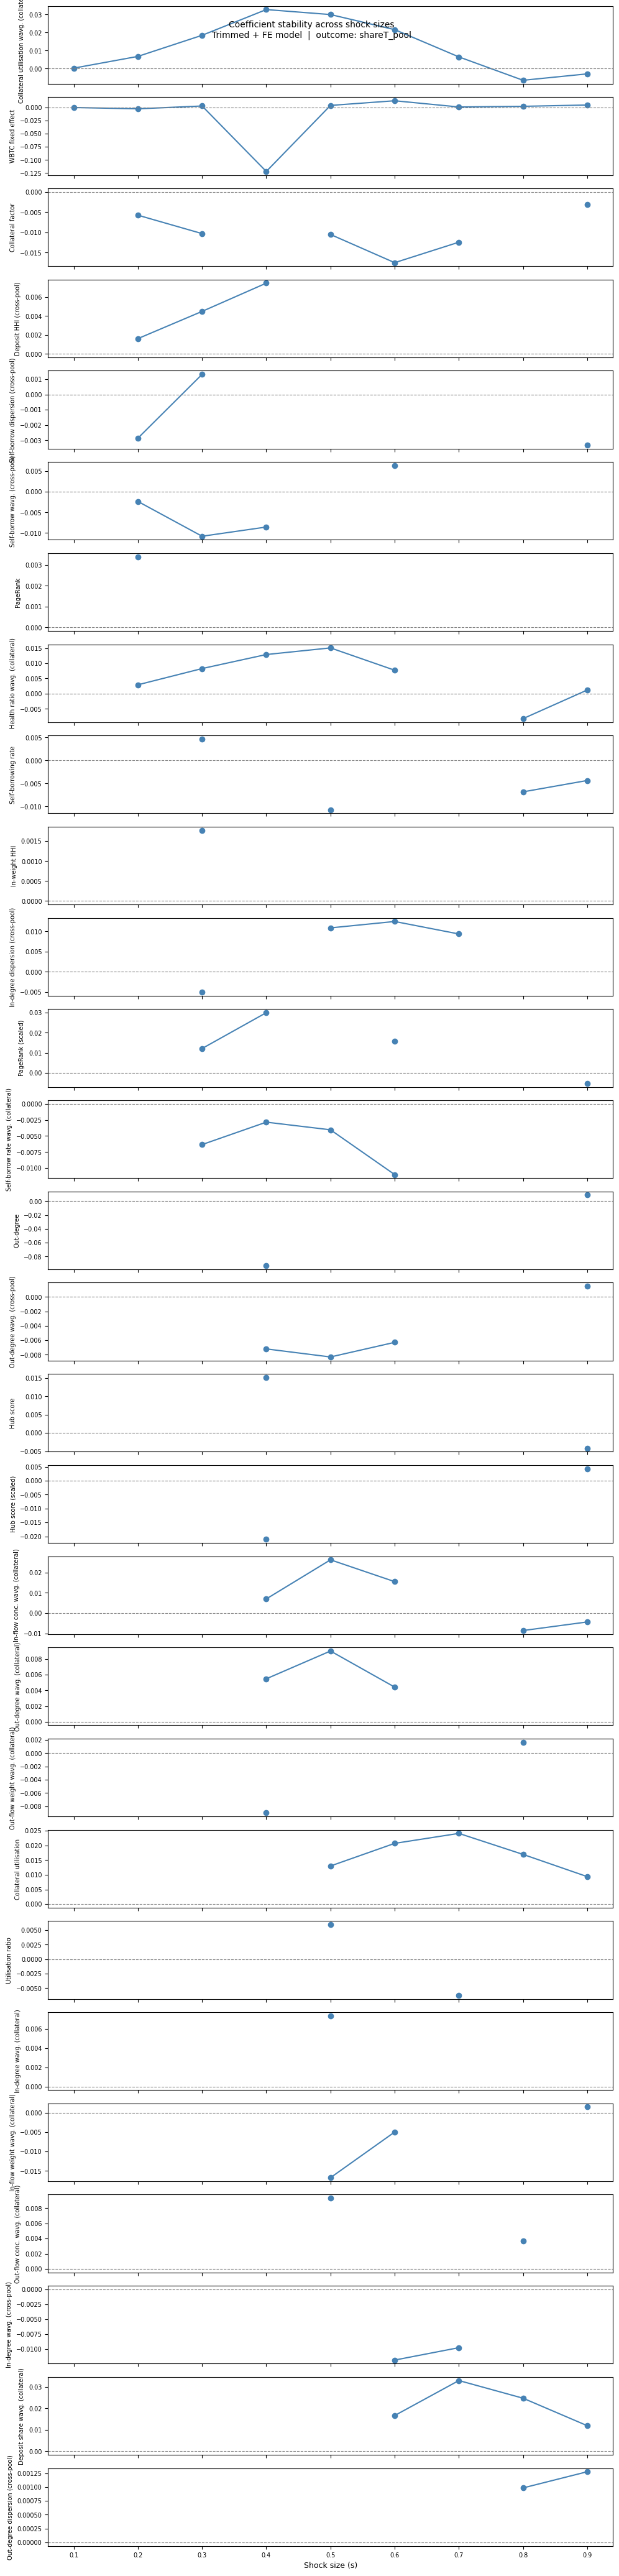

Saved: coef_stability_across_sizes.pdf


In [74]:
# ══════════════════════════════════════════════════════════════════
# Main loop
# ══════════════════════════════════════════════════════════════════
for SHOCK_SIZE in SHOCK_SIZES:
    sep = "=" * 70
    print(f"\n{sep}")
    print(f"  SHOCK SIZE = {SHOCK_SIZE:.2f}")
    print(f"{sep}")
 
    # ------------------------------------------------------------------
    # 1. Build sample
    # ------------------------------------------------------------------
    regr_postbreak = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == SHOCK_SIZE) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()
 
    # Outcome variables

    regr_postbreak['b'] = (
        regr_postbreak['B'] / regr_postbreak['assets']
    )
 
    n_eth  = (regr_postbreak['shockAsset'] == 'ETH').sum()
    n_wbtc = (regr_postbreak['shockAsset'] == 'WBTC').sum()
    print(f"  Post-break sample: N={len(regr_postbreak)}  "
          f"(ETH={n_eth}, WBTC={n_wbtc})")
 
    if len(regr_postbreak) < 20:
        print(f"  *** Too few observations — skipping size {SHOCK_SIZE:.2f}")
        results_by_size[SHOCK_SIZE] = None
        continue
 
    # ------------------------------------------------------------------
    # 2. Build X / y
    # ------------------------------------------------------------------
    theory_vars_flat = [v for g in GROUPS_flat for v in features[g]]
    available        = [v for v in theory_vars_flat if v in regr_postbreak.columns]
    missing          = [v for v in theory_vars_flat if v not in regr_postbreak.columns]
    if missing:
        print(f"  *** Missing predictors: {missing}")
 
    X_th  = regr_postbreak[available].copy()
    y_th  = regr_postbreak['shareT_pool'].copy()
    dt_th = regr_postbreak['date'].copy()
 
    row_mask = X_th.notna().all(axis=1) & y_th.notna()
    X_th     = X_th.loc[row_mask]
    y_th     = y_th.loc[row_mask]
    dt_th    = dt_th.loc[row_mask]
 
    X_th      = X_th.loc[:, X_th.std() > 0]
    available = list(X_th.columns)
 
    # ------------------------------------------------------------------
    # 3. Train / test split (chronological, trimmed to TEST_END_DATE)
    # ------------------------------------------------------------------
    end_mask = dt_th.values <= pd.Timestamp(TEST_END_DATE)
    X_th     = X_th[end_mask]
    y_th     = y_th[end_mask]
    dt_th    = dt_th[end_mask]
 
    n_total = len(y_th)
    n_test  = int(n_total * TEST_SIZE)
    n_train = n_total - n_test
 
    if n_train < 10 or n_test < 5:
        print(f"  *** Train={n_train} / Test={n_test} — too small, skipping.")
        results_by_size[SHOCK_SIZE] = None
        continue
 
    X_tr_raw = X_th.iloc[:n_train]
    X_te_raw = X_th.iloc[n_train:]
    y_tr     = y_th.iloc[:n_train]
    y_te     = y_th.iloc[n_train:]
    dates_tr = dt_th.iloc[:n_train]
    dates_te = dt_th.iloc[n_train:]
 
    print(f"  Train: N={n_train}  {dates_tr.min().date()} → {dates_tr.max().date()}")
    print(f"  Test:  N={n_test}   {dates_te.min().date()} → {dates_te.max().date()}")

    # ------------------------------------------------------------------
    # 4. Scale (fit on train only)
    # ------------------------------------------------------------------
    scaler   = StandardScaler()
    X_tr_sc  = pd.DataFrame(
        scaler.fit_transform(X_tr_raw),
        columns=available, index=X_tr_raw.index
    )
    X_te_sc  = pd.DataFrame(
        scaler.transform(X_te_raw),
        columns=available, index=X_te_raw.index
    )
 

    # ------------------------------------------------------------------
    # 5. OLS — full theory specification (Step 4)
    # ------------------------------------------------------------------
    X_tr_const = sm.add_constant(X_tr_sc)
    model_hac  = sm.OLS(y_tr, X_tr_const).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )
    model_hc3  = sm.OLS(y_tr, X_tr_const).fit(cov_type='HC3')

    # Out-of-sample (Step 6)
    y_pred_full = model_hac.predict(
        sm.add_constant(X_te_sc, has_constant='add')
    )
    res_full  = y_te - y_pred_full
    r2_full   = 1 - (res_full**2).sum() / ((y_te - y_te.mean())**2).sum()
    rmse_full = np.sqrt((res_full**2).mean())

    print(f"\n  [Full OLS]  Train R²={model_hac.rsquared:.4f}  "
          f"Test R²={r2_full:.4f}  N vars={len(available)}")

    # ------------------------------------------------------------------
    # 6. LASSO robustness check (Step 8)
    # ------------------------------------------------------------------
    tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
    lasso_cv = LassoCV(
        cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
        max_iter=10_000, random_state=42
    )
    lasso_cv.fit(X_tr_sc, y_tr)

    lambdas   = lasso_cv.alphas_
    mse_path  = lasso_cv.mse_path_
    mean_mse  = mse_path.mean(axis=1)
    std_mse   = mse_path.std(axis=1) / np.sqrt(N_SPLITS)
    lam_min   = lasso_cv.alpha_
    min_idx   = np.argmin(mean_mse)
    threshold = mean_mse[min_idx] + std_mse[min_idx]
    within_1se = np.where(mean_mse <= threshold)[0]
    lam_1se   = lambdas[within_1se[0]]

    coefs_min = pd.Series(lasso_cv.coef_, index=available)
    coefs_1se = pd.Series(
        Lasso(alpha=lam_1se, max_iter=10_000)
        .fit(X_tr_sc, y_tr).coef_,
        index=available
    )

    selected_min = coefs_min[coefs_min != 0].index.tolist()
    selected_1se = coefs_1se[coefs_1se != 0].index.tolist()
    print(f"  [LASSO]  λ_min={lam_min:.6f} ({len(selected_min)} vars)  "
          f"λ_1se={lam_1se:.6f} ({len(selected_1se)} vars)")

    # ------------------------------------------------------------------
    # 7. OLS on LASSO-selected vars (Step 9)
    # ------------------------------------------------------------------
    if not selected_min:
        print("  *** LASSO selected 0 vars — using all available.")
        selected_min = available

    X_tr_lasso   = sm.add_constant(X_tr_sc[selected_min])
    model_lasso  = sm.OLS(y_tr, X_tr_lasso).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )
    y_pred_lasso = model_lasso.predict(
        sm.add_constant(X_te_sc[selected_min], has_constant='add')
    )
    res_lasso  = y_te - y_pred_lasso
    r2_lasso   = 1 - (res_lasso**2).sum() / ((y_te - y_te.mean())**2).sum()
    rmse_lasso = np.sqrt((res_lasso**2).mean())

    print(f"  [LASSO OLS]  Train R²={model_lasso.rsquared:.4f}  "
          f"Test R²={r2_lasso:.4f}  N vars={len(selected_min)}")

    # ------------------------------------------------------------------
    # 8. Trimmed model — no FE (Step 10)
    # ------------------------------------------------------------------
    sig_vars = [
        v for v in selected_min
        if model_lasso.pvalues[v] < ALPHA
    ]
    if not sig_vars:
        print("  *** No significant vars at ALPHA — relaxing to p<0.05 for trimmed model.")
        sig_vars = [
            v for v in selected_min
            if model_lasso.pvalues[v] < 0.05
        ]

    if sig_vars:
        X_tr_trim   = sm.add_constant(X_tr_sc[sig_vars])
        model_trim  = sm.OLS(y_tr, X_tr_trim).fit(
            cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
        )
        y_pred_trim = model_trim.predict(
            sm.add_constant(X_te_sc[sig_vars], has_constant='add')
        )
        res_trim  = y_te - y_pred_trim
        r2_trim   = 1 - (res_trim**2).sum() / ((y_te - y_te.mean())**2).sum()
        rmse_trim = np.sqrt((res_trim**2).mean())
        mae_trim  = res_trim.abs().mean()

        print(f"  [Trimmed no FE]  Train R²={model_trim.rsquared:.4f}  "
              f"Test R²={r2_trim:.4f}  N vars={len(sig_vars)}")
    else:
        print("  *** No significant vars — skipping trimmed models.")
        model_trim = None
        r2_trim = rmse_trim = mae_trim = np.nan

    # ------------------------------------------------------------------
    # 9. Trimmed model — with WBTC FE (Step 11)
    # ------------------------------------------------------------------
    if model_trim is not None:
        X_tr_sc['fe_WBTC'] = (
            regr_postbreak.loc[X_tr_raw.index, 'shockAsset'] == 'WBTC'
        ).astype(float).values
        X_te_sc['fe_WBTC'] = (
            regr_postbreak.loc[X_te_raw.index, 'shockAsset'] == 'WBTC'
        ).astype(float).values

        sig_vars_fe      = list(dict.fromkeys(sig_vars + ['fe_WBTC']))
        X_tr_trim_fe     = sm.add_constant(X_tr_sc[sig_vars_fe].astype(float))
        model_trim_fe    = sm.OLS(y_tr.astype(float),
                                  X_tr_trim_fe.astype(float)).fit(
            cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
        )
        X_te_trim_fe     = sm.add_constant(
            X_te_sc[sig_vars_fe].astype(float), has_constant='add'
        )
        y_pred_trim_fe   = model_trim_fe.predict(X_te_trim_fe.astype(float))
        res_trim_fe      = y_te - y_pred_trim_fe
        r2_trim_fe       = 1 - (res_trim_fe**2).sum() / ((y_te - y_te.mean())**2).sum()
        rmse_trim_fe     = np.sqrt((res_trim_fe**2).mean())
        mae_trim_fe      = res_trim_fe.abs().mean()

        print(f"  [Trimmed + FE]   Train R²={model_trim_fe.rsquared:.4f}  "
              f"Test R²={r2_trim_fe:.4f}  N vars={len(sig_vars_fe)}")

        # Clean up FE column so it doesn't persist into next iteration
        X_tr_sc.drop(columns=['fe_WBTC'], inplace=True, errors='ignore')
        X_te_sc.drop(columns=['fe_WBTC'], inplace=True, errors='ignore')
    else:
        model_trim_fe = None
        r2_trim_fe = rmse_trim_fe = mae_trim_fe = np.nan
        sig_vars_fe = []

    # ------------------------------------------------------------------
    # 10. Save diagnostic figure for this shock size
    # ------------------------------------------------------------------
    if model_trim is not None and model_trim_fe is not None:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))

        for col_idx, (model, y_pred, res, label, r2_te_) in enumerate([
            (model_trim,    y_pred_trim,    res_trim,    'Trimmed no FE', r2_trim),
            (model_trim_fe, y_pred_trim_fe, res_trim_fe, 'Trimmed + FE',  r2_trim_fe),
        ]):
            # actual vs predicted — train
            ax = axes[0, col_idx * 2]
            ax.scatter(model.fittedvalues, y_tr, s=4, alpha=0.3, color='steelblue')
            lims = [y_tr.min(), y_tr.max()]
            ax.plot(lims, lims, 'k--', lw=0.8)
            ax.set_xlabel('Predicted', fontsize=9)
            ax.set_ylabel('Actual', fontsize=9)
            ax.set_title(f'{label} — Train  R²={model.rsquared:.3f}', fontsize=9, loc='left')

            # actual vs predicted — test
            ax = axes[0, col_idx * 2 + 1]
            ax.scatter(y_pred, y_te, s=4, alpha=0.3, color='coral')
            lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
            ax.plot(lims, lims, 'k--', lw=0.8)
            ax.set_xlabel('Predicted', fontsize=9)
            ax.set_ylabel('Actual', fontsize=9)
            ax.set_title(f'{label} — Test  R²={r2_te_:.3f}', fontsize=9, loc='left')

            # coefficients
            ax = axes[1, col_idx * 2]
            params_r, ci_r = get_renamed_params(model)
            order_r = params_r.sort_values().index
            y_pos   = range(len(order_r))
            ax.barh(y_pos, params_r[order_r],
                    color=['coral' if v < 0 else 'steelblue' for v in params_r[order_r]],
                    alpha=0.7)
            ax.errorbar(
                params_r[order_r], y_pos,
                xerr=[params_r[order_r] - ci_r.loc[order_r, 0],
                      ci_r.loc[order_r, 1] - params_r[order_r]],
                fmt='none', color='black', capsize=3, lw=1
            )
            ax.set_yticks(y_pos)
            ax.set_yticklabels(order_r, fontsize=7)
            ax.axvline(0, color='gray', lw=0.8)
            ax.set_xlabel('Coef (HAC) 95% CI', fontsize=9)
            ax.set_title(f'{label} — Coefficients', fontsize=9, loc='left')

            # residuals over time
            ax = axes[1, col_idx * 2 + 1]
            ax.plot(dates_tr, model.resid.values, color='steelblue',
                    lw=0.5, alpha=0.6, label='Train')
            ax.plot(dates_te, res.values, color='coral',
                    lw=0.5, alpha=0.6, label='Test')
            ax.axhline(0, color='gray', lw=0.8, ls='--')
            ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)
            ax.set_ylabel('Residual', fontsize=9)
            ax.set_title(f'{label} — Residuals', fontsize=9, loc='left')
            ax.legend(fontsize=7)
            ax.tick_params(axis='x', rotation=30, labelsize=7)

        fig.suptitle(
            f'Model comparison — shock size s={SHOCK_SIZE:.2f}\n'
            f'Liquidity shock (ETH & WBTC)\n'
            f'No FE: Train R²={model_trim.rsquared:.3f}  Test R²={r2_trim:.3f}  |  '
            f'With FE: Train R²={model_trim_fe.rsquared:.3f}  Test R²={r2_trim_fe:.3f}',
            fontsize=10
        )
        plt.tight_layout()
        fname = f'appendix_fe_comparison_size{int(SHOCK_SIZE*100):03d}.pdf'
        plt.savefig(fname, bbox_inches='tight', dpi=150)
        plt.close()
        print(f"  Saved: {fname}")

    # ------------------------------------------------------------------
    # 11. Store results
    # ------------------------------------------------------------------
    results_by_size[SHOCK_SIZE] = {
        'n_obs':          len(y_th),
        'n_train':        n_train,
        'n_test':         n_test,
        'n_vars_full':    len(available),
        'n_vars_lasso':   len(selected_min),
        'n_vars_trim':    len(sig_vars),
        'n_vars_trim_fe': len(sig_vars_fe),
        # train R²
        'r2_train_full':     model_hac.rsquared,
        'r2_train_lasso':    model_lasso.rsquared,
        'r2_train_trim':     model_trim.rsquared   if model_trim    else np.nan,
        'r2_train_trim_fe':  model_trim_fe.rsquared if model_trim_fe else np.nan,
        # test R²
        'r2_test_full':      r2_full,
        'r2_test_lasso':     r2_lasso,
        'r2_test_trim':      r2_trim,
        'r2_test_trim_fe':   r2_trim_fe,
        # RMSE
        'rmse_full':         rmse_full,
        'rmse_lasso':        rmse_lasso,
        'rmse_trim':         rmse_trim,
        'rmse_trim_fe':      rmse_trim_fe,
        # significant variables retained
        'sig_vars':          sig_vars,
        'sig_vars_fe':       sig_vars_fe,
        # model objects (for further inspection)
        'model_full':        model_hac,
        'model_lasso':       model_lasso,
        'model_trim':        model_trim,
        'model_trim_fe':     model_trim_fe,
    }

# ══════════════════════════════════════════════════════════════════
# Summary comparison table across all shock sizes
# ══════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 95)
print("  SUMMARY — results across all shock sizes")
print("=" * 95)
header = (
    f"  {'Size':>5}  {'N':>5}  "
    f"{'Full TR²':>9} {'Full TeR²':>10}  "
    f"{'Lasso TR²':>10} {'Lasso TeR²':>11}  "
    f"{'Trim TR²':>9} {'Trim TeR²':>10}  "
    f"{'TrimFE TR²':>11} {'TrimFE TeR²':>12}  "
    f"{'Vars(trim)':>11}"
)
print(header)
print("  " + "-" * 93)

summary_rows = []
for sz, res in results_by_size.items():
    if res is None:
        print(f"  {sz:>5.2f}  {'—':>5}  (skipped)")
        continue
    row = (
        f"  {sz:>5.2f}  {res['n_obs']:>5}  "
        f"{res['r2_train_full']:>9.4f} {res['r2_test_full']:>10.4f}  "
        f"{res['r2_train_lasso']:>10.4f} {res['r2_test_lasso']:>11.4f}  "
        f"{res['r2_train_trim']:>9.4f} {res['r2_test_trim']:>10.4f}  "
        f"{res['r2_train_trim_fe']:>11.4f} {res['r2_test_trim_fe']:>12.4f}  "
        f"{res['n_vars_trim']:>11}"
    )
    print(row)
    summary_rows.append({
        'shock_size':       sz,
        'n_obs':            res['n_obs'],
        'r2_train_full':    res['r2_train_full'],
        'r2_test_full':     res['r2_test_full'],
        'r2_train_lasso':   res['r2_train_lasso'],
        'r2_test_lasso':    res['r2_test_lasso'],
        'r2_train_trim':    res['r2_train_trim'],
        'r2_test_trim':     res['r2_test_trim'],
        'r2_train_trim_fe': res['r2_train_trim_fe'],
        'r2_test_trim_fe':  res['r2_test_trim_fe'],
        'rmse_trim_fe':     res['rmse_trim_fe'],
        'n_vars_trim':      res['n_vars_trim'],
    })

summary_df = pd.DataFrame(summary_rows)
print("\n  summary_df is available for further use.")
print("  results_by_size[sz]['model_trim_fe'].summary() for any shock size.")

# ══════════════════════════════════════════════════════════════════
# Optional: coefficient stability plot across sizes
# ══════════════════════════════════════════════════════════════════
# Collect coefficients of the trimmed+FE model across shock sizes
all_coefs = []
for sz, res in results_by_size.items():
    if res is None or res['model_trim_fe'] is None:
        continue
    coef_series = res['model_trim_fe'].params.drop('const')
    coef_series.name = sz
    all_coefs.append(coef_series)

if all_coefs:
    coef_df = pd.DataFrame(all_coefs).T  # rows=variables, cols=shock_sizes
    coef_df.columns = [f"s={c:.2f}" for c in coef_df.columns]

    n_vars = len(coef_df)
    fig, axes = plt.subplots(
        n_vars, 1,
        figsize=(10, max(3, n_vars * 1.5)),
        sharex=True
    )
    if n_vars == 1:
        axes = [axes]

    for ax, var in zip(axes, coef_df.index):
        label = rename_map.get(var, var)
        ax.plot(
            [float(c.split('=')[1]) for c in coef_df.columns],
            coef_df.loc[var].values,
            marker='o', lw=1.5, color='steelblue'
        )
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.set_ylabel(label, fontsize=7, labelpad=4)
        ax.tick_params(labelsize=7)

    axes[-1].set_xlabel('Shock size (s)', fontsize=9)
    fig.suptitle(
        'Coefficient stability across shock sizes\n'
        'Trimmed + FE model  |  outcome: shareT_pool',
        fontsize=10
    )
    plt.tight_layout()
    plt.savefig('coef_stability_across_sizes.pdf',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: coef_stability_across_sizes.pdf")

## 4. Focus: shock size = 50% — Trimmed+FE with vs without borrowers' features

This section re-runs the trimmed+FE pipeline at `s = 0.50` under two feature specifications:
- **Without borrowers**: `pool_own`, `pool_cross`, `pool_centrality`, `collaterals_network`, `collaterals_financial`
- **With borrowers**: same as above plus `borrowers_network` and `borrowers_financial`

Outputs: printed comparison table, coefficient table, side-by-side diagnostic figure, and a LaTeX table.



  FOCUS: s=0.50  —  Trimmed+FE  with vs without borrowers' features

  ── Specification: Without borrowers ──
    Train: N=1607  2021-01-01 → 2023-03-15
    Test:  N=401   2023-03-15 → 2023-10-01
    Predictors available: 30
    LASSO selected: 20 vars  →  significant: 14 vars
    [Trimmed no FE]  Train R²=0.8354  Test R²=0.8683  N vars=14
    [Trimmed + FE]   Train R²=0.8357  Test R²=0.8709  N vars=15

  ── Specification: With borrowers ──
    *** Missing predictors: ['borrowers-pctDeposit-wavg']
    Train: N=1607  2021-01-01 → 2023-03-15
    Test:  N=401   2023-03-15 → 2023-10-01
    Predictors available: 39
    LASSO selected: 22 vars  →  significant: 14 vars
    [Trimmed no FE]  Train R²=0.8377  Test R²=0.8270  N vars=14
    [Trimmed + FE]   Train R²=0.8406  Test R²=0.8278  N vars=15


  COMPARISON TABLE — s=0.50  |  Trimmed model (no FE)
  Model                                     Train R²   Test R²       RMSE        MAE  N vars
  ------------------------------------------------

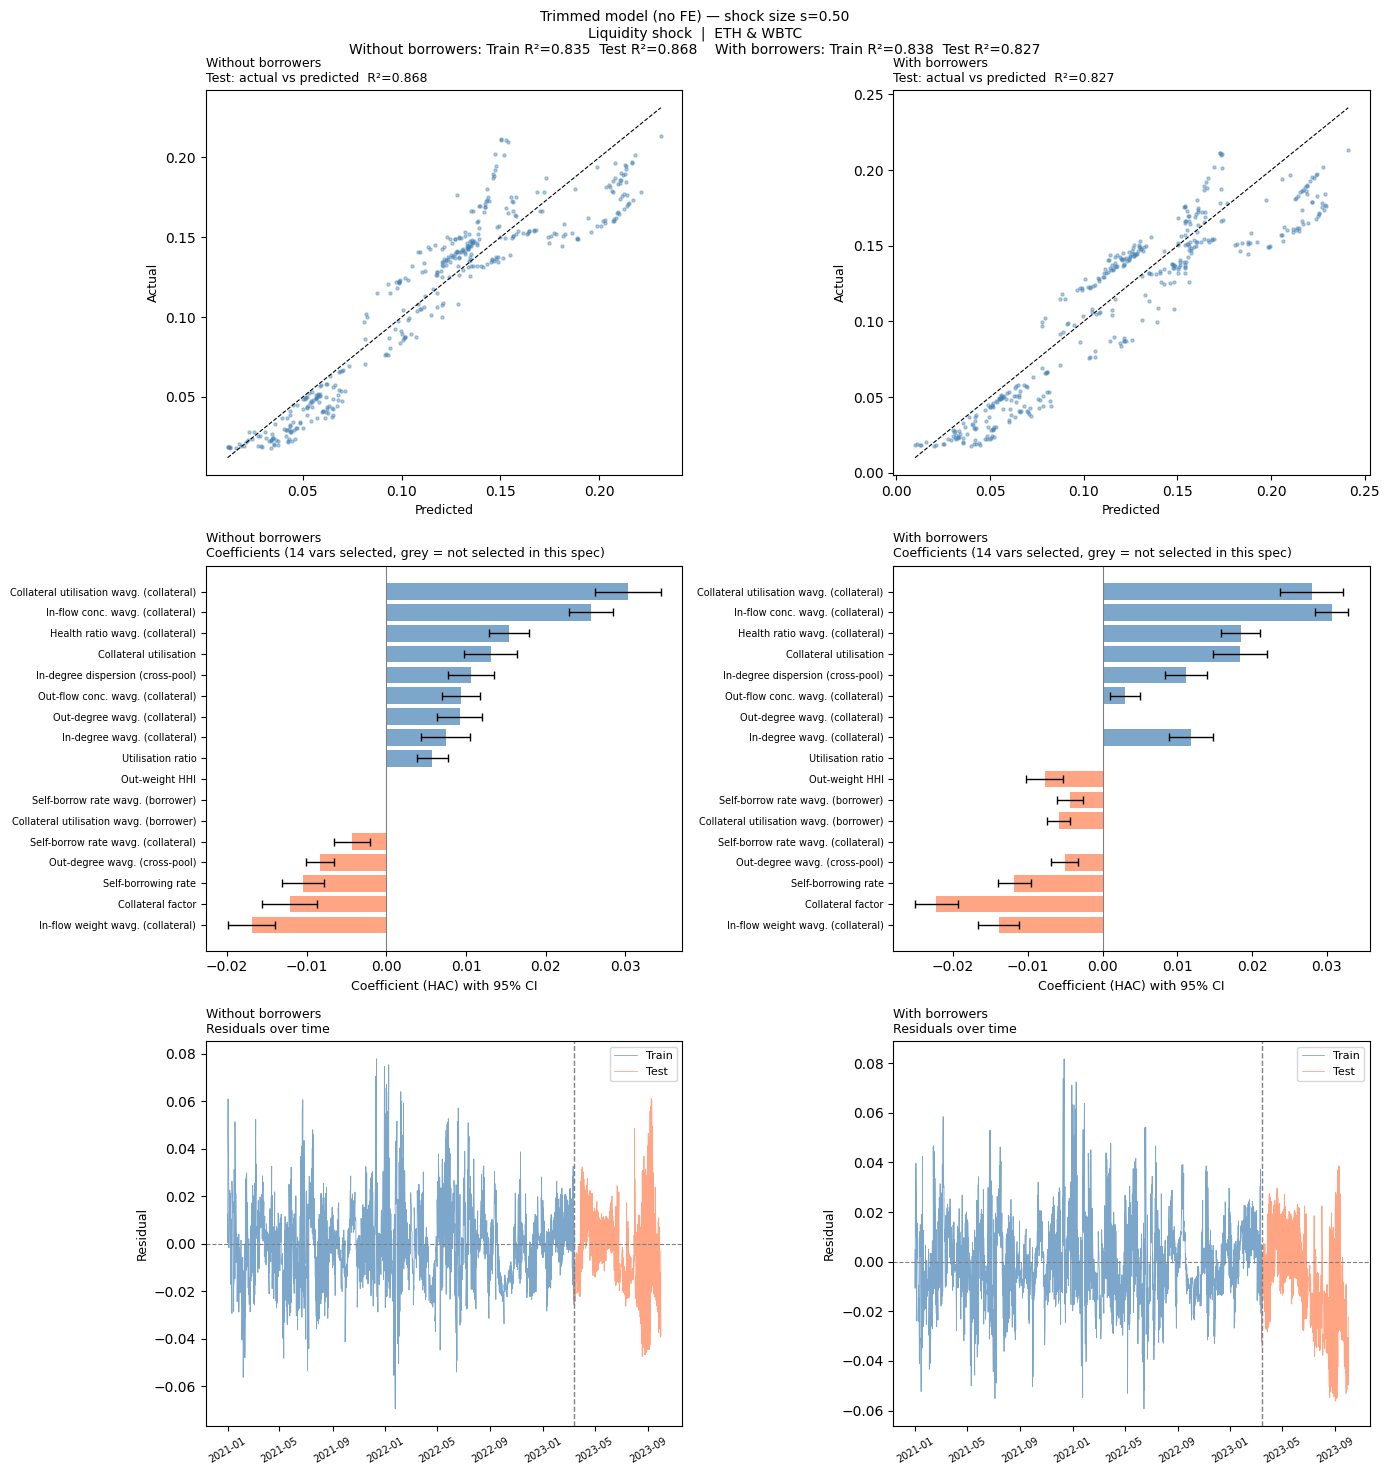


Saved: focus_borrowers_comparison_nofe_size050.pdf


LaTeX figure environment:
\begin{figure}[ht]
\captionsetup{justification=justified,
              singlelinecheck=false}
\includegraphics[width=\linewidth]
    {figures/focus_borrowers_comparison_nofe_size050.pdf}
\caption{Model comparison --- Trimmed model (no asset fixed effect)
without and with borrowers' features, liquidity risk
$\ell_{t,j}$ (ETH and WBTC, $s = 0.5$).
Each column of panels shows the same three diagnostics for the
two specifications side by side.
\textit{Row 1}: actual against fitted values on the held-out
test set (blue dots); the dashed line is the 45-degree line of
perfect prediction.
\textit{Row 2}: HAC-estimated coefficients with 95\,\% confidence
intervals, ordered by magnitude; grey bars indicate variables
present in the union of both specifications but not selected in
that particular model.
\textit{Row 3}: residuals over time for the training (blue) and
test (coral) periods, separated by the dashed vertic

In [77]:
# ══════════════════════════════════════════════════════════════════
# FOCUS: shock size = 50% — trimmed+FE with vs without borrowers
# ══════════════════════════════════════════════════════════════════
# At this point results_by_size[0.5] already contains the baseline
# trimmed+FE model (without borrowers, since GROUPS_flat has them
# commented out). Here we re-run the full pipeline a second time
# adding borrowers_network and borrowers_financial, then compare.
# ══════════════════════════════════════════════════════════════════

print("\n\n" + "=" * 70)
print("  FOCUS: s=0.50  —  Trimmed+FE  with vs without borrowers' features")
print("=" * 70)

FOCUS_SIZE = 0.50

# ── Retrieve the baseline result from the main loop ───────────────
if results_by_size.get(FOCUS_SIZE) is None:
    raise ValueError("results_by_size[0.5] is None — re-run the main loop first.")

base_res = results_by_size[FOCUS_SIZE]

# ── Rebuild sample (identical to main loop) ───────────────────────
regr_postbreak_focus = final_updated[
    (final_updated['date']             >= break_date) &
    (final_updated['size']             == FOCUS_SIZE) &
    (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
    (final_updated['health_threshold'] == HEALTH_THRESHOLD)
].copy()

# ── Two feature specifications ─────────────────────────────────────
GROUPS_no_borrow = [
    'pool_own', 'pool_cross', 'pool_centrality',
    'collaterals_network', 'collaterals_financial',
]
GROUPS_with_borrow = [
    'pool_own', 'pool_cross', 'pool_centrality',
    'collaterals_network', 'collaterals_financial',
    'borrowers_network',   'borrowers_financial',
]

spec_labels = {
    'no_borrowers':   'Without borrowers',
    'with_borrowers': 'With borrowers',
}

focus_results = {}

for spec_key, GROUPS in [
    ('no_borrowers',   GROUPS_no_borrow),
    ('with_borrowers', GROUPS_with_borrow),
]:
    print(f"\n  ── Specification: {spec_labels[spec_key]} ──")

    theory_vars = [v for g in GROUPS for v in features[g]]
    available_f = [v for v in theory_vars if v in regr_postbreak_focus.columns]
    missing_f   = [v for v in theory_vars if v not in regr_postbreak_focus.columns]
    if missing_f:
        print(f"    *** Missing predictors: {missing_f}")

    X_f  = regr_postbreak_focus[available_f].copy()
    y_f  = regr_postbreak_focus['shareT_pool'].copy()
    dt_f = regr_postbreak_focus['date'].copy()

    row_mask = X_f.notna().all(axis=1) & y_f.notna()
    X_f  = X_f.loc[row_mask]
    y_f  = y_f.loc[row_mask]
    dt_f = dt_f.loc[row_mask]

    X_f        = X_f.loc[:, X_f.std() > 0]
    available_f = list(X_f.columns)

    end_mask = dt_f.values <= pd.Timestamp(TEST_END_DATE)
    X_f  = X_f[end_mask]
    y_f  = y_f[end_mask]
    dt_f = dt_f[end_mask]

    n_total_f = len(y_f)
    n_test_f  = int(n_total_f * TEST_SIZE)
    n_train_f = n_total_f - n_test_f

    X_tr_raw_f = X_f.iloc[:n_train_f]
    X_te_raw_f = X_f.iloc[n_train_f:]
    y_tr_f     = y_f.iloc[:n_train_f]
    y_te_f     = y_f.iloc[n_train_f:]
    dates_tr_f = dt_f.iloc[:n_train_f]
    dates_te_f = dt_f.iloc[n_train_f:]

    print(f"    Train: N={n_train_f}  {dates_tr_f.min().date()} → {dates_tr_f.max().date()}")
    print(f"    Test:  N={n_test_f}   {dates_te_f.min().date()} → {dates_te_f.max().date()}")
    print(f"    Predictors available: {len(available_f)}")

    # Scale
    scaler_f  = StandardScaler()
    X_tr_sc_f = pd.DataFrame(
        scaler_f.fit_transform(X_tr_raw_f),
        columns=available_f, index=X_tr_raw_f.index
    )
    X_te_sc_f = pd.DataFrame(
        scaler_f.transform(X_te_raw_f),
        columns=available_f, index=X_te_raw_f.index
    )

    # LASSO
    tscv_f    = TimeSeriesSplit(n_splits=N_SPLITS)
    lasso_f   = LassoCV(cv=tscv_f, n_alphas=LAMBDA_GRID_SIZE,
                        max_iter=10_000, random_state=42)
    lasso_f.fit(X_tr_sc_f, y_tr_f)

    coefs_f      = pd.Series(lasso_f.coef_, index=available_f)
    selected_f   = coefs_f[coefs_f != 0].index.tolist() or available_f

    X_tr_lasso_f = sm.add_constant(X_tr_sc_f[selected_f])
    model_lasso_f = sm.OLS(y_tr_f, X_tr_lasso_f).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )

    sig_f = [v for v in selected_f if model_lasso_f.pvalues[v] < ALPHA]
    if not sig_f:
        sig_f = [v for v in selected_f if model_lasso_f.pvalues[v] < 0.05]

    print(f"    LASSO selected: {len(selected_f)} vars  →  significant: {len(sig_f)} vars")

    if not sig_f:
        print("    *** No significant vars — skipping this specification.")
        focus_results[spec_key] = None
        continue

    # Trimmed no FE
    X_tr_trim_f  = sm.add_constant(X_tr_sc_f[sig_f])
    model_trim_f = sm.OLS(y_tr_f, X_tr_trim_f).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )
    y_pred_trim_f = model_trim_f.predict(
        sm.add_constant(X_te_sc_f[sig_f], has_constant='add')
    )
    res_trim_f = y_te_f - y_pred_trim_f
    r2_trim_f  = 1 - (res_trim_f**2).sum() / ((y_te_f - y_te_f.mean())**2).sum()
    rmse_trim_f = np.sqrt((res_trim_f**2).mean())
    mae_trim_f  = res_trim_f.abs().mean()

    # Trimmed + WBTC FE
    X_tr_sc_f['fe_WBTC'] = (
        regr_postbreak_focus.loc[X_tr_raw_f.index, 'shockAsset'] == 'WBTC'
    ).astype(float).values
    X_te_sc_f['fe_WBTC'] = (
        regr_postbreak_focus.loc[X_te_raw_f.index, 'shockAsset'] == 'WBTC'
    ).astype(float).values

    sig_fe_f     = list(dict.fromkeys(sig_f + ['fe_WBTC']))
    X_tr_fe_f    = sm.add_constant(X_tr_sc_f[sig_fe_f].astype(float))
    model_fe_f   = sm.OLS(y_tr_f.astype(float),
                          X_tr_fe_f.astype(float)).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )
    X_te_fe_f    = sm.add_constant(X_te_sc_f[sig_fe_f].astype(float),
                                   has_constant='add')
    y_pred_fe_f  = model_fe_f.predict(X_te_fe_f.astype(float))
    res_fe_f     = y_te_f - y_pred_fe_f
    r2_fe_f      = 1 - (res_fe_f**2).sum() / ((y_te_f - y_te_f.mean())**2).sum()
    rmse_fe_f    = np.sqrt((res_fe_f**2).mean())
    mae_fe_f     = res_fe_f.abs().mean()

    X_tr_sc_f.drop(columns=['fe_WBTC'], inplace=True, errors='ignore')
    X_te_sc_f.drop(columns=['fe_WBTC'], inplace=True, errors='ignore')

    print(f"    [Trimmed no FE]  Train R²={model_trim_f.rsquared:.4f}  "
          f"Test R²={r2_trim_f:.4f}  N vars={len(sig_f)}")
    print(f"    [Trimmed + FE]   Train R²={model_fe_f.rsquared:.4f}  "
          f"Test R²={r2_fe_f:.4f}  N vars={len(sig_fe_f)}")

    focus_results[spec_key] = {
        'sig_vars':         sig_f,
        'sig_vars_fe':      sig_fe_f,
        'model_trim':       model_trim_f,
        'model_fe':         model_fe_f,
        'y_tr':             y_tr_f,
        'y_te':             y_te_f,
        'y_pred_trim':      y_pred_trim_f,
        'y_pred_fe':        y_pred_fe_f,
        'res_trim':         res_trim_f,
        'res_fe':           res_fe_f,
        'r2_trim':          r2_trim_f,
        'r2_fe':            r2_fe_f,
        'rmse_trim':        rmse_trim_f,
        'rmse_fe':          rmse_fe_f,
        'mae_trim':         mae_trim_f,
        'mae_fe':           mae_fe_f,
        'dates_tr':         dates_tr_f,
        'dates_te':         dates_te_f,
        'available':        available_f,
        'n_train':          n_train_f,
        'n_test':           n_test_f,
    }

# ── Printed comparison table ─────────────────────────────────────
print(f"\n\n{'='*75}")
print(f"  COMPARISON TABLE — s=0.50  |  Trimmed model (no FE)")
print(f"{'='*75}")
print(f"  {'Model':<40} {'Train R²':>9} {'Test R²':>9} "
      f"{'RMSE':>10} {'MAE':>10} {'N vars':>7}")
print(f"  {'-'*75}")

for spec_key, label in spec_labels.items():
    r = focus_results.get(spec_key)
    if r is None:
        print(f"  {label + ' (FAILED)':<40}")
        continue
    print(f"  {label:<40} "
          f"{r['model_trim'].rsquared:>9.4f} "
          f"{r['r2_trim']:>9.4f} "
          f"{r['rmse_trim']:>10.6f} "
          f"{r['mae_trim']:>10.6f} "
          f"{len(r['sig_vars']):>7}")

# ── Coefficient comparison table ───────────────────────────────────
print(f"\n  {'='*75}")
print(f"  COEFFICIENT TABLE — Trimmed no FE  (HAC standard errors)")
print(f"  {'='*75}")

all_vars_union = list(dict.fromkeys(
    (focus_results['no_borrowers']['sig_vars']   if focus_results.get('no_borrowers')   else []) +
    (focus_results['with_borrowers']['sig_vars'] if focus_results.get('with_borrowers') else [])
))

print(f"\n  {'Variable':<45} "
      f"{'No borr. coef':>14} {'No borr. p':>11}  "
      f"{'With borr. coef':>16} {'With borr. p':>13}")
print(f"  {'-'*105}")

for var in all_vars_union:
    label = rename_map.get(var, var)
    row   = f"  {label:<45} "
    for spec_key in ['no_borrowers', 'with_borrowers']:
        r = focus_results.get(spec_key)
        if r is None:
            row += f"{'—':>14} {'—':>11}  "
            continue
        model = r['model_trim']
        if var in model.params.index:
            c = model.params[var]
            p = model.pvalues[var]
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            row += f"{c:>12.4f}{sig:>2} {p:>11.4f}  "
        else:
            row += f"{'(not selected)':>14} {'':>11}  "
    print(row)

print(f"\n  Significance: *** p<0.001  ** p<0.01  * p<0.05")

# ── Side-by-side diagnostic figure ────────────────────────────────
specs_to_plot = [
    (k, spec_labels[k])
    for k in ['no_borrowers', 'with_borrowers']
    if focus_results.get(k) is not None
]

if specs_to_plot:
    n_specs = len(specs_to_plot)
    fig, axes = plt.subplots(3, n_specs, figsize=(7 * n_specs, 15))
    if n_specs == 1:
        axes = axes[:, np.newaxis]

    # ── Shared variable order across both panels ──────────────────
    all_vars_union_plot = list(dict.fromkeys(
        (focus_results['no_borrowers']['sig_vars']   if focus_results.get('no_borrowers')   else []) +
        (focus_results['with_borrowers']['sig_vars'] if focus_results.get('with_borrowers') else [])
    ))

    anchor_key   = 'no_borrowers' if focus_results.get('no_borrowers') else specs_to_plot[0][0]
    anchor_model = focus_results[anchor_key]['model_trim']

    def get_coef(model, var):
        return model.params[var] if var in model.params.index else 0.0

    union_coefs_anchor = pd.Series(
        {rename_map.get(v, v): get_coef(anchor_model, v) for v in all_vars_union_plot}
    )
    shared_order = union_coefs_anchor.sort_values().index.tolist()
    y_pos_shared = range(len(shared_order))

    for col_idx, (spec_key, spec_label) in enumerate(specs_to_plot):
        r = focus_results[spec_key]

        # Row 0: actual vs predicted (test set)
        ax = axes[0, col_idx]
        ax.scatter(r['y_pred_trim'], r['y_te'],
                   s=5, alpha=0.4, color='steelblue')
        lims = [min(r['y_te'].min(), r['y_pred_trim'].min()),
                max(r['y_te'].max(), r['y_pred_trim'].max())]
        ax.plot(lims, lims, 'k--', lw=0.8)
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('Actual', fontsize=9)
        ax.set_title(
            f'{spec_label}\nTest: actual vs predicted  '
            f'R²={r["r2_trim"]:.3f}',
            fontsize=9, loc='left'
        )

        # Row 1: coefficients — shared order, no-FE model
        ax = axes[1, col_idx]
        model = r['model_trim']

        params_aligned = pd.Series(
            {rename_map.get(v, v): get_coef(model, v) for v in all_vars_union_plot}
        ).reindex(shared_order)

        def get_ci(model, var):
            if var in model.params.index:
                return model.conf_int().loc[var].values
            return np.array([0.0, 0.0])

        ci_lower = pd.Series(
            {rename_map.get(v, v): get_ci(model, v)[0] for v in all_vars_union_plot}
        ).reindex(shared_order)
        ci_upper = pd.Series(
            {rename_map.get(v, v): get_ci(model, v)[1] for v in all_vars_union_plot}
        ).reindex(shared_order)

        selected_renamed = [rename_map.get(v, v) for v in r['sig_vars']]
        bar_colors = [
            ('coral' if params_aligned[lbl] < 0 else 'steelblue')
            if lbl in selected_renamed else 'lightgrey'
            for lbl in shared_order
        ]

        for i, (lbl, c, col) in enumerate(
            zip(shared_order, params_aligned, bar_colors)
        ):
            ax.barh(i, c, color=col, alpha=0.7)

        for i, lbl in enumerate(shared_order):
            if lbl in selected_renamed and params_aligned[lbl] != 0:
                ax.errorbar(
                    params_aligned[lbl], i,
                    xerr=[[params_aligned[lbl] - ci_lower[lbl]],
                          [ci_upper[lbl] - params_aligned[lbl]]],
                    fmt='none', color='black', capsize=3, lw=1
                )

        ax.set_yticks(y_pos_shared)
        ax.set_yticklabels(shared_order, fontsize=7)
        ax.axvline(0, color='gray', lw=0.8)
        ax.set_xlabel('Coefficient (HAC) with 95% CI', fontsize=9)
        ax.set_title(
            f'{spec_label}\nCoefficients ({len(r["sig_vars"])} vars selected'
            f', grey = not selected in this spec)',
            fontsize=9, loc='left'
        )

        # Row 2: residuals over time
        ax = axes[2, col_idx]
        ax.plot(r['dates_tr'], r['model_trim'].resid.values,
                color='steelblue', lw=0.6, alpha=0.7, label='Train')
        ax.plot(r['dates_te'], r['res_trim'].values,
                color='coral', lw=0.6, alpha=0.7, label='Test')
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.axvline(r['dates_te'].min(), color='gray', ls='--', lw=1)
        ax.set_ylabel('Residual', fontsize=9)
        ax.set_title(f'{spec_label}\nResiduals over time', fontsize=9, loc='left')
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=30, labelsize=7)

    fig.suptitle(
        f'Trimmed model (no FE) — shock size s=0.50\n'
        f'Liquidity shock  |  ETH & WBTC\n'
        f'Without borrowers: Train R²='
        f'{focus_results["no_borrowers"]["model_trim"].rsquared:.3f}  '
        f'Test R²={focus_results["no_borrowers"]["r2_trim"]:.3f}    '
        f'With borrowers: Train R²='
        f'{focus_results["with_borrowers"]["model_trim"].rsquared:.3f}  '
        f'Test R²={focus_results["with_borrowers"]["r2_trim"]:.3f}',
        fontsize=10
    )
    plt.tight_layout()
    plt.savefig('focus_borrowers_comparison_nofe_size050.pdf',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("\nSaved: focus_borrowers_comparison_nofe_size050.pdf")

# ── LaTeX figure + table ──────────────────────────────────────────
latex_figure = r"""\begin{figure}[ht]
\captionsetup{justification=justified,
              singlelinecheck=false}
\includegraphics[width=\linewidth]
    {figures/focus_borrowers_comparison_nofe_size050.pdf}
\caption{Model comparison --- Trimmed model (no asset fixed effect)
without and with borrowers' features, liquidity risk
$\ell_{t,j}$ (ETH and WBTC, $s = 0.5$).
Each column of panels shows the same three diagnostics for the
two specifications side by side.
\textit{Row 1}: actual against fitted values on the held-out
test set (blue dots); the dashed line is the 45-degree line of
perfect prediction.
\textit{Row 2}: HAC-estimated coefficients with 95\,\% confidence
intervals, ordered by magnitude; grey bars indicate variables
present in the union of both specifications but not selected in
that particular model.
\textit{Row 3}: residuals over time for the training (blue) and
test (coral) periods, separated by the dashed vertical line at
the train/test boundary (October 2023).
Adding borrowers' network and financial features leaves the
collateral-side coefficients largely stable while providing
additional explanatory power on the test set.}
\label{fig:borrowers_comparison_nofe}
\end{figure}"""

print('\n\nLaTeX figure environment:')
print(latex_figure)

with open('focus_borrowers_figure_nofe.tex', 'w') as f:
    f.write(latex_figure)
print('Saved: focus_borrowers_figure_nofe.tex')

# ── LaTeX coefficient table ───────────────────────────────────────
def focus_to_latex_nofe(focus_results, rename_map):
    lines = []
    lines.append(r'\begin{table}[ht]')
    lines.append(r'\centering')
    lines.append(r'\begin{threeparttable}')
    lines.append(
        r' caption{Trimmed model (no FE): without vs with borrowers'
        r' features --- shock size $s=0.50$, ETH and WBTC}'
    )
    lines.append(r'\label{tab:borrowers_comparison_nofe}')
    lines.append(r'\begin{tabular}{lrrrr}')
    lines.append(r'\toprule')
    lines.append(
        r'& \multicolumn{2}{c}{Without borrowers} '
        r'& \multicolumn{2}{c}{With borrowers} \\'
    )
    lines.append(r'\cmidrule(lr){2-3}\cmidrule(lr){4-5}')
    lines.append(r'Variable & Coef. & $p$-value & Coef. & $p$-value \\')
    lines.append(r'\midrule')

    all_vars = list(dict.fromkeys(
        (focus_results['no_borrowers']['sig_vars']   if focus_results.get('no_borrowers')   else []) +
        (focus_results['with_borrowers']['sig_vars'] if focus_results.get('with_borrowers') else [])
    ))

    group_labels_latex = {
        'pool_own':               'Own-pool characteristics',
        'pool_centrality':        'Pool centrality',
        'pool_cross':             'Cross-pool linkages',
        'collaterals_network':    'Collateral network features',
        'collaterals_financial':  'Collateral financial features',
        'borrowers_network':      'Borrower network features',
        'borrowers_financial':    'Borrower financial features',
        'other':                  'Other',
    }

    def group_of(var):
        for g in GROUPS_with_borrow:
            if var in features.get(g, []):
                return g
        return 'other'

    current_group = None
    for var in all_vars:
        g = group_of(var)
        if g != current_group:
            current_group = g
            lines.append(r'\midrule')
            lines.append(
                f'\\multicolumn{{5}}{{l}}'
                f'{{\\textit{{{group_labels_latex.get(g, g)}}}}}\\\\'
            )
        label = rename_map.get(var, var).replace('_', r'\_').replace('&', r'\&')

        def fmt_cell(spec_key):
            r = focus_results.get(spec_key)
            if r is None:
                return '---', '---'
            m = r['model_trim']
            if var not in m.params.index:
                return '---', '---'
            c = m.params[var]
            p = m.pvalues[var]
            sig = (r'$^{***}$' if p < 0.001 else
                   r'$^{**}$'  if p < 0.01  else
                   r'$^{*}$'   if p < 0.05  else '')
            return f'{c:.4f}{sig}', f'{p:.4f}'

        c1, p1 = fmt_cell('no_borrowers')
        c2, p2 = fmt_cell('with_borrowers')
        lines.append(
            f'\\texttt{{{label}}} & {c1} & {p1} & {c2} & {p2} \\\\'
        )

    lines.append(r'\midrule')
    for stat_label, getter in [
        ('Train $R^2$', lambda k: f'{focus_results[k]["model_trim"].rsquared:.4f}'
                                   if focus_results.get(k) else '---'),
        ('Test $R^2$',  lambda k: f'{focus_results[k]["r2_trim"]:.4f}'
                                   if focus_results.get(k) else '---'),
        ('RMSE',        lambda k: f'{focus_results[k]["rmse_trim"]:.6f}'
                                   if focus_results.get(k) else '---'),
        ('N vars',      lambda k: str(len(focus_results[k]["sig_vars"]))
                                   if focus_results.get(k) else '---'),
    ]:
        v1 = getter('no_borrowers')
        v2 = getter('with_borrowers')
        lines.append(f'{stat_label} & \\multicolumn{{2}}{{c}}{{{v1}}} '
                     f'& \\multicolumn{{2}}{{c}}{{{v2}}} \\\\')

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(r'\begin{tablenotes}[flushleft]')
    lines.append(r'\footnotesize')
    lines.append(
        r'\item \textit{Notes}: HAC standard errors (4 lags). '
        r'Significant variables selected by LASSO ($\lambda_{\min}$) '
        r'then trimmed at $\alpha=0.001$. No asset fixed effect. '
        r'$^{*}p<0.05$, $^{**}p<0.01$, $^{***}p<0.001$.'
    )
    lines.append(r'\end{tablenotes}')
    lines.append(r'\end{threeparttable}')
    lines.append(r'\end{table}')
    return '\n'.join(lines)

latex_nofe = focus_to_latex_nofe(focus_results, rename_map)
print('\n\nLaTeX coefficient table:')
print(latex_nofe)

with open('focus_borrowers_comparison_nofe_size050.tex', 'w') as f:
    f.write(latex_nofe)
print('Saved: focus_borrowers_comparison_nofe_size050.tex')


In [76]:
# Run this to check what we have available
res = results_by_size[0.5]
print(f"Model type: {type(res['model_trim'])}")
print(f"N train: {res['n_train']}")
print(f"N test:  {res['n_test']}")

Model type: <class 'statsmodels.regression.linear_model.RegressionResultsWrapper'>
N train: 1607
N test:  401
